In [57]:
import os
import pyabf
import matplotlib.pyplot as plt
import numpy as np

In [51]:
def plot_current_clamp_abf(abf_path):
    """
    Given an ABF file, verify it is current clamp, then plot:
    - All voltage sweeps (Y) in one subplot.
    - All command currents (X) in a second subplot.
    """
    abf = pyabf.ABF(abf_path)

    # Check for current clamp mode
    if abf.adcUnits[1] != "pA":
        print(f"Skipping {os.path.basename(abf_path)}: not a current clamp file.")
        return

    # Prepare figure
    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"Current Clamp Sweeps: {os.path.basename(abf_path)}")

    # Overlay all sweeps
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        axs[0].plot(abf.sweepX * 1000, abf.sweepY, alpha=0.6)  # convert X to ms
        axs[1].plot(abf.sweepX * 1000, abf.sweepC, alpha=0.6)

    # Labels and formatting
    axs[0].set_ylabel("Membrane Voltage (mV)")
    axs[1].set_ylabel("Command Current (pA)")
    axs[1].set_xlabel("Time (ms)")
    axs[0].set_title("Voltage Responses")
    axs[1].set_title("Injected Currents")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

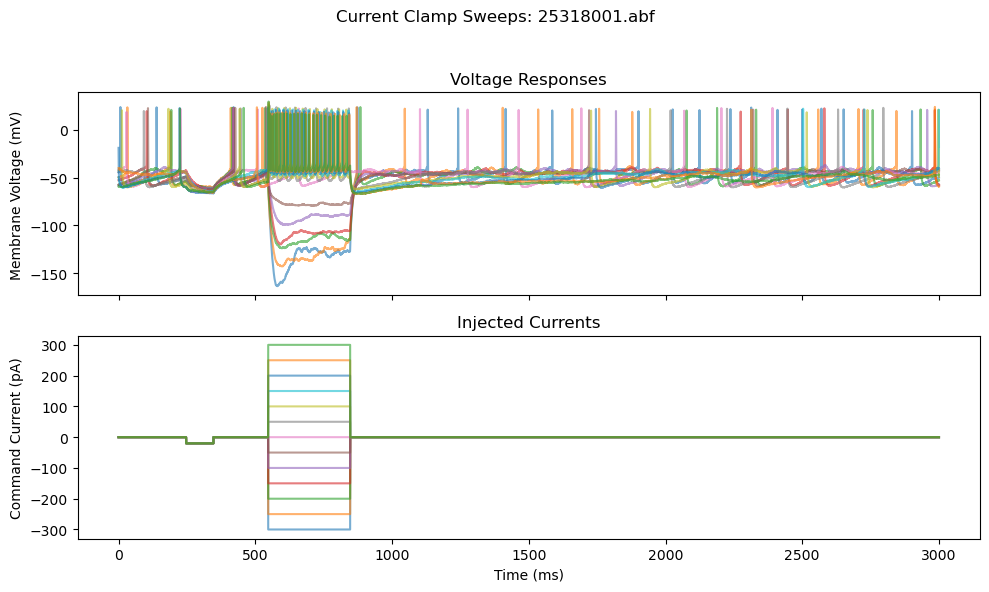

In [53]:
plot_current_clamp_abf("/Users/jayashri/Desktop/03182025/25318001.abf")

In [55]:
abf = pyabf.ABF("/Users/jayashri/Desktop/03182025/25318001.abf")

In [95]:
def count_spikes_in_stim_window(voltage, current, sample_rate, threshold=25):
    """
    Count spikes only during the stimulus window defined by a deviation in command current.
    """
    # Detect stimulus start: first deviation ≥ 20 pA
    stim_start_idx = np.where(np.abs(current) >= 20)[0]
    if stim_start_idx.size == 0:
        return 0  # No stimulus found

    stim_start_idx = stim_start_idx[0]

    # Detect end of stimulus: return to near 0 pA (within ±5 pA)
    stim_end_idx = stim_start_idx
    for i in range(stim_start_idx + 1, len(current)):
        if np.abs(current[i]) < 5:
            stim_end_idx = i
            break

    # Slice voltage trace within stimulus window
    stim_voltage = voltage[stim_start_idx:stim_end_idx]

    # Count upward threshold crossings
    crossings = (stim_voltage[:-1] < threshold) & (stim_voltage[1:] >= threshold)
    return np.count_nonzero(crossings)

def analyze_spiking_vs_current_in_stim_window(abf_path):
    """
    For a current clamp ABF file, plot spike count (during stimulus only)
    vs the mean command current in the stimulus window.
    """
    abf = pyabf.ABF(abf_path)

    # Check for current clamp by unit
    if abf.adcUnits[1] != "pA":
        print(f"Skipping {os.path.basename(abf_path)}: not a current clamp file.")
        return

    spike_counts = []
    stim_currents = []

    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        voltage = abf.sweepY
        current = abf.sweepC
        sample_rate = abf.dataRate

        # Detect stimulus window and spikes
        stim_start_idx = np.where(np.abs(current) >= 20)[0]
        if stim_start_idx.size == 0:
            continue  # Skip if no stimulus

        stim_start_idx = stim_start_idx[0]
        stim_end_idx = stim_start_idx
        for i in range(stim_start_idx + 1, len(current)):
            if np.abs(current[i]) < 5:
                stim_end_idx = i
                break

        stim_voltage = voltage[stim_start_idx:stim_end_idx]
        stim_current = current[stim_start_idx:stim_end_idx]
        spikes = count_spikes_in_stim_window(voltage, current, sample_rate)

        spike_counts.append(spikes)
        stim_currents.append(np.mean(stim_current))  # Mean command current in stim window

    if len(spike_counts) == 0:
        print(f"No valid stimuli found in {os.path.basename(abf_path)}.")
        return

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(stim_currents, spike_counts, marker='o', color='black')
    plt.xlabel("Command Current (pA)")
    plt.ylabel("Spike Count (during stimulus)")
    plt.title(f"Spike Count vs Stimulus Current\n{os.path.basename(abf_path)}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

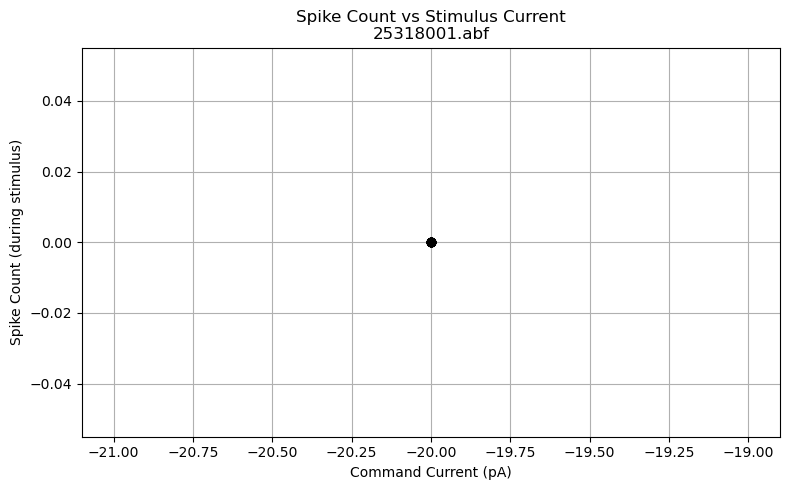

In [97]:
analyze_spiking_vs_current_in_stim_window("/Users/jayashri/Desktop/03182025/25318001.abf")